# [Title]

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

In [59]:
import pandas as pd
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np
import joblib
import matplotlib.pyplot as plt
import random
import folium
import json
from shapely.geometry import mapping

In [60]:
from libpysal.weights import Queen, KNN
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import degree
from torch_geometric.data import HeteroData
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax as pyg_softmax
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

In [3]:
random.seed(99)
np.random.seed(99)
torch.manual_seed(99)

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

## Research questions

[[ go back to the top ]](#Table-of-contents)

## Data

[[ go back to the top ]](#Table-of-contents)

*[Note: a table that describes the selected variables for analysis and modelling is required - see the example below.]*

| Variable                            | Type         | Description                                                             |Notes   |
|-------------------------------------|--------------|-------------------------------------------------------------------------|---|
| Burglary crime rate                 | Numeric      | The burglary rate of MSOAs. Used as dependent variables in regression.  |   |
| Temperature                         | Numeric      | The daytime temperature                                                 |   |
| Indicator of Inner or Outer London  | Categorical  | Whether the MSOA is in Inner London.                                    |   |
| ......  | ......  | ......                                    |   |

### Reading files and parsing geometries

In [4]:
county_node = pd.read_csv("data/processed_data/county_node.csv")
county_y = pd.read_csv("data/processed_data/county_y.csv")
team_node = pd.read_csv("data/processed_data/team_node.csv")

In [4]:
county_node.head()

,geoid,county_name,state_code,state_name,population,density,median_income,median_age,pct_high_income,pct_bachelors,pct_white,unemployment_rate,geometry
0,13101,Echols,GA,Georgia,3709.0,0.034063,59489.0,30.5,0.075109,0.097539,0.581019,0.016844,"POLYGON ((-83.135777 30.721966, -83.130212 30...."
1,18167,Vigo,IN,Indiana,106109.0,1.015008,52976.0,36.3,0.046794,0.155849,0.839533,0.056966,"POLYGON ((-87.61005 39.282232, -87.597545 39.2..."
2,23031,York,ME,Maine,216731.0,0.844237,88333.0,45.3,0.110947,0.232381,0.901255,0.033853,"POLYGON ((-70.9890367618669 43.7921536087332, ..."
3,27031,Cook,MN,Minnesota,5635.0,0.014978,72638.0,53.0,0.080812,0.266534,0.836380,0.022193,"POLYGON ((-91.0320682870099 48.188527229104, -..."
4,38013,Burke,ND,North Dakota,2156.0,0.007543,91591.0,39.7,0.198009,0.195270,0.865028,0.037255,"POLYGON ((-102.938955609487 48.9992792883949, ..."


In [5]:
county_node.dtypes

geoid                  int64
county_name              str
state_code               str
state_name               str
population           float64
density              float64
median_income        float64
median_age           float64
pct_high_income      float64
pct_bachelors        float64
pct_white            float64
unemployment_rate    float64
geometry                 str
dtype: object

In [6]:
county_y.head()

,geoid,state_code,county_name,dma,boston_celtics,atlanta_hawks,brooklyn_nets,charlotte_hornets,chicago_bulls,cleveland_cavaliers,...,oklahoma_city_thunder,orlando_magic,philadelphia_76ers,phoenix_suns,portland_trail_blazers,sacramento_kings,san_antonio_spurs,toronto_raptors,utah_jazz,washington_wizards
0,13101,GA,Echols,Tallahassee FL-Thomasville GA,0.071538,0.090085,0.021196,0.010598,0.025038,0.019673,...,0.005648,0.075303,0.009413,0.026356,0.009538,0.013115,0.014308,0.010731,0.021461,0.009198
1,18167,IN,Vigo,Terre Haute IN,0.058642,0.015849,0.014264,0.011094,0.076017,0.023891,...,0.010199,0.024222,0.007649,0.026771,0.008652,0.011536,0.011536,0.005768,0.015917,0.009215
2,23031,ME,York,Portland-Auburn ME,0.601683,0.012279,0.012279,0.000000,0.013993,0.013993,...,0.000000,0.019409,0.006470,0.019409,0.006268,0.006268,0.006268,0.006268,0.012406,0.006203
3,27031,MN,Cook,Duluth MN-Superior WI,0.034347,0.006327,0.009039,0.006327,0.030667,0.007360,...,0.008396,0.010686,0.004580,0.018318,0.006297,0.006297,0.005724,0.004580,0.010304,0.004416
4,38013,ND,Burke,Minot-Bismarck-Dickinson(Williston) ND,0.081041,0.014182,0.014182,0.012156,0.039293,0.012279,...,0.008621,0.020691,0.006897,0.055177,0.018300,0.013071,0.011764,0.006536,0.027786,0.006946


In [7]:
county_y.dtypes[:5]

geoid               int64
state_code            str
county_name           str
dma                   str
boston_celtics    float64
dtype: object

In [8]:
team_node.head()

,team,value,win_pct,age,championships,geometry
0,Golden State Warriors,1.100000e+10,0.556098,80,7,POINT (-122.3875 37.768056)
1,Los Angeles Lakers,1.000000e+10,0.551220,78,17,POINT (-118.267222 34.043056)
2,New York Knicks,9.750000e+09,0.580488,80,2,POINT (-73.993611 40.750556)
3,LA Clippers,7.500000e+09,0.558537,56,0,POINT (-118.267222 34.043056)
4,Boston Celtics,6.700000e+09,0.704878,80,18,POINT (-71.062228 42.366303)


In [9]:
team_node.dtypes

team                 str
value            float64
win_pct          float64
age                int64
championships      int64
geometry             str
dtype: object

In [5]:
# convert the geo dataframes to gpd dataframes
county_gdf = gpd.GeoDataFrame(
    county_node,
    geometry=gpd.GeoSeries.from_wkt(county_node['geometry']),
    crs='EPSG:4326'
)

team_gdf = gpd.GeoDataFrame(
    team_node,
    geometry=gpd.GeoSeries.from_wkt(team_node['geometry']),
    crs='EPSG:4326'
)

In [6]:
# project both gdfs to a meters-based CRS for accurate distance computation
# EPSG:5070 is Albers Equal Area — standard for contiguous US analysis
county_gdf = county_gdf.to_crs('EPSG:5070')
team_gdf = team_gdf.to_crs('EPSG:5070')

### Modifying Y labels

In [7]:
# identify the 30 team affinity columns (everything except geoid and dma)
affinity_cols = [c for c in county_y.columns if c not in ['geoid', 'state_code', 'county_name', 'dma']]

In [8]:
# merge y values onto county_gdf so everything is aligned by geoid
county_gdf = county_gdf.merge(county_y[['geoid', 'dma']+affinity_cols], on='geoid', how='left')

In [9]:
# check that all counties merged with one affinity example
county_gdf[pd.isna(county_gdf["boston_celtics"])].shape[0]

0

In [10]:
# Y matrix: rows = counties, cols = teams
Y = county_gdf[affinity_cols].values.astype(np.float32)  # shape: [3144 x 30]
Y.shape

(3144, 30)

In [11]:
# sanity check: each row should sum to ~1
assert np.allclose(Y.sum(axis=1), 1.0, atol=1e-4), "fandom affinity rows don't sum to 1"

In [12]:
# DMA encoding — map each DMA name to an integer index
dma_names = county_gdf['dma'].unique()
dma_to_idx = {dma: i for i, dma in enumerate(dma_names)}
county_dma_idx = county_gdf['dma'].map(dma_to_idx).values  # shape: [3144]
# county_dma_idx[i] gives the DMA index for county i

### Building node index mappings

In [13]:
# county index: position in county_gdf is the node index
county_gdf = county_gdf.reset_index(drop=True)
county_gdf['node_idx'] = county_gdf.index  # 0 to 3143

In [14]:
# build a geoid -> county node_idx lookup for any future joins
geoid_to_idx = dict(zip(county_gdf['geoid'], county_gdf['node_idx']))

In [15]:
# also store the affinity column order so team node indices align with Y columns
team_gdf['team_normalized'] = team_gdf['team'].str.lower().str.replace(' ', '_')

# reindex team_gdf so its row order matches affinity_cols exactly
team_gdf = (
    team_gdf
    .set_index('team_normalized')
    .loc[affinity_cols]
    .reset_index()
)

# reassign node indices after reorder
team_gdf['node_idx'] = team_gdf.index  # 0 to 29

# and build a team name -> team node_idx lookupteam_to_idx = dict(zip(team_gdf['team'], team_gdf['node_idx']))

# verify alignment
assert list(team_gdf['team_normalized']) == affinity_cols, \
    "reindex failed — check for name mismatches between team_gdf and affinity_cols"

### Normalizing X features

In [16]:
# county features
county_feature_cols = ['density', 'median_income', 'median_age', 'pct_high_income', 'pct_bachelors', 'pct_white', 'unemployment_rate']
county_scaler = StandardScaler()
county_features_scaled = county_scaler.fit_transform(
    county_gdf[county_feature_cols].values
)  # shape: [3144 x 7]

In [17]:
county_features_scaled.shape

(3144, 7)

In [18]:
# team features
team_feature_cols = ['value', 'win_pct', 'age', 'championships']
team_scaler = StandardScaler()
team_features_scaled = team_scaler.fit_transform(
    team_gdf[team_feature_cols].values
)  # shape: [30 x 4]

In [19]:
team_features_scaled.shape

(30, 4)

In [20]:
# store scalers to normalize expansion team features at inference time using the same statistics
joblib.dump(county_scaler, 'county_scaler.pkl')
joblib.dump(team_scaler, 'team_scaler.pkl')

['team_scaler.pkl']

### County-county spatial edge matrix

In [21]:
# build queen contiguity weights from county geometries
# this finds all county pairs that share a border or corner
w_queen = Queen.from_dataframe(county_gdf, geom_col='geometry')

/var/folders/nz/kcn7dvz905jcjvnj8yh855mc0000gn/T/ipykernel_85910/89630705.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = Queen.from_dataframe(county_gdf, geom_col='geometry')
/Users/lukebenson/Desktop/UCL/Spatial_Data_Science/assessment/.venv/lib/python3.12/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
 There are 6 islands with ids: 1049, 1596, 1973, 2026, 2590, 2890.
  W.__init__(self, neighbors, ids=ids, **kw)


In [22]:
# identify islands — counties with no queen neighbors
island_idx = [i for i, neighbors in w_queen.neighbors.items() 
              if len(neighbors) == 0]
print(f"islands (no queen neighbors): {len(island_idx)}")
print(county_gdf.loc[island_idx, ['county_name', 'state_code']])

islands (no queen neighbors): 6
         county_name state_code
1049       Nantucket         MA
1596        Honolulu         HI
1973        San Juan         WA
2026  Aleutians West         AK
2590           Kauai         HI
2890          Hawaii         HI


In [23]:
# build KNN weights as fallback (K=3 nearest centroids)
w_knn = KNN.from_dataframe(county_gdf, geom_col='geometry', k=3)

/Users/lukebenson/Desktop/UCL/Spatial_Data_Science/assessment/.venv/lib/python3.12/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [24]:
# combine: use queen edges for all counties,
# supplement with KNN edges only for island counties
src_cc, dst_cc = [], []

for i in range(len(county_gdf)):
    if len(w_queen.neighbors[i]) > 0:
        # normal county — use queen contiguity
        for j in w_queen.neighbors[i]:
            src_cc.append(i)
            dst_cc.append(j)
    else:
        # island county — fall back to KNN
        for j in w_knn.neighbors[i]:
            src_cc.append(i)
            dst_cc.append(j)

In [25]:
# binary weights — all edges weighted 1.0
edge_index_cc_init = torch.tensor([src_cc, dst_cc], dtype=torch.long)
edge_weight_cc_init = torch.ones(len(src_cc), dtype=torch.float32)

print(f"county-county edges (directed ones): {edge_index_cc_init.shape[1]}")

county-county edges (directed ones): 18256


### County-team spatial edge matrix

In [176]:
K = 5  # each county connects to its 5 nearest teams
LAMBDA = 500_000  # decay length in meters (~500km)

In [177]:
# extract centroid coordinates for counties
county_centroids = np.array([
    [geom.centroid.x, geom.centroid.y] for geom in county_gdf.geometry
])  # [3144 x 2]

In [178]:
# extract arena coordinates for teams
team_coords = np.array([
    [geom.x, geom.y] for geom in team_gdf.geometry
])  # [30 x 2]

In [179]:
# compute full pairwise distance matrix
dist_matrix = euclidean_distances(county_centroids, team_coords)  # shape: [3144 x 30], using meters

# and apply distance decay
decay_matrix = np.exp(-dist_matrix / LAMBDA)  # [3144 x 30]

In [180]:
# sparsify: for each county keep only K nearest teams
# zero out all but the K largest decay values per row
src_ct, dst_ct, weight_ct = [], [], []

for i in range(len(county_gdf)):
    # indices of K nearest teams (largest decay = smallest distance)
    top_k = np.argsort(decay_matrix[i])[::-1][:K]
    for j in top_k:
        src_ct.append(i)
        dst_ct.append(j)
        weight_ct.append(decay_matrix[i, j])

In [181]:
# to torch
edge_index_ct = torch.tensor([src_ct, dst_ct], dtype=torch.long)  # [2 x E_ct]
edge_weight_ct = torch.tensor(weight_ct, dtype=torch.float32)      # [E_ct]

print(f"county-team edges: {edge_index_ct.shape[1]}") # should be 3144 * K = 15,720 edges for K=5

county-team edges: 15720


### Degree normalization of edge matrices

In [182]:
# first, make edge index symmetric by adding reverse edges where missing
# stack original edges with their reverse
row = torch.cat([edge_index_cc_init[0], edge_index_cc_init[1]])
col = torch.cat([edge_index_cc_init[1], edge_index_cc_init[0]])

# remove duplicate edges (e.g. queen edges that were already bidirectional)
edge_pairs = torch.stack([row, col], dim=0)
edge_pairs = torch.unique(edge_pairs, dim=1)

edge_index_cc = edge_pairs  # now fully symmetric
edge_weight_cc = torch.ones(edge_index_cc.shape[1], dtype=torch.float32)

print(f"county-county edges after symmetrization: {edge_index_cc.shape[1]}")

county-county edges after symmetrization: 18272


In [183]:
# --- county-county: symmetric normalization D^(-1/2) A D^(-1/2) ---
num_counties = len(county_gdf)
num_teams = len(team_gdf)

deg_cc = degree(edge_index_cc[0], num_nodes=num_counties)
deg_cc_inv_sqrt = deg_cc.pow(-0.5)
deg_cc_inv_sqrt[deg_cc_inv_sqrt == float('inf')] = 0

edge_weight_cc_norm = (
    deg_cc_inv_sqrt[edge_index_cc[0]] *
    edge_weight_cc *
    deg_cc_inv_sqrt[edge_index_cc[1]]
)  # [E_cc]

In [184]:
# --- county-team: row normalization D^(-1) A ---
deg_ct = degree(edge_index_ct[0], num_nodes=num_counties)
deg_ct_inv = deg_ct.pow(-1)
deg_ct_inv[deg_ct_inv == float('inf')] = 0

edge_weight_ct_norm = (
    deg_ct_inv[edge_index_ct[0]] *
    edge_weight_ct
)  # [E_ct]

In [185]:
print(f"cc edges: {edge_index_cc.shape[1]}, ct edges: {edge_index_ct.shape[1]}")

cc edges: 18272, ct edges: 15720


In [186]:
data = HeteroData()

# node features
data['county'].x = torch.tensor(county_features_scaled, dtype=torch.float32)  # [3144 x 3]
data['team'].x = torch.tensor(team_features_scaled, dtype=torch.float32)       # [30 x 2]

# labels and DMA mapping on county nodes
data['county'].y = torch.tensor(Y, dtype=torch.float32)                        # [3144 x 30]
data['county'].dma_idx = torch.tensor(county_dma_idx, dtype=torch.long)        # [3144]

# county-county edges
data['county', 'adj', 'county'].edge_index = edge_index_cc                     # [2 x E_cc]
data['county', 'adj', 'county'].edge_weight = edge_weight_cc_norm              # [E_cc]

# county-team edges
data['county', 'near', 'team'].edge_index = edge_index_ct                      # [2 x E_ct]
data['county', 'near', 'team'].edge_weight = edge_weight_ct_norm               # [E_ct]

In [187]:
print(data)

HeteroData(
  county={
    x=[3144, 7],
    y=[3144, 30],
    dma_idx=[3144],
  },
  team={ x=[30, 4] },
  (county, adj, county)={
    edge_index=[2, 18272],
    edge_weight=[18272],
  },
  (county, near, team)={
    edge_index=[2, 15720],
    edge_weight=[15720],
  }
)


## Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodology is strongly encouraged]*

### Stratified fold construction

In [224]:
# rank teams by total fandom share across all counties
team_total_fandom = Y.sum(axis=0)  # [30] total fandom per team
team_fandom_rank = team_total_fandom.argsort()[::-1]  # high to low

In [225]:
# snake/zigzag fold assignment by fandom rank
num_folds = 5
fold_assignments = np.zeros(30, dtype=int)
fold_sequence = list(range(num_folds)) + list(range(num_folds-1, -1, -1))
for i, team_idx in enumerate(team_fandom_rank):
    fold_assignments[team_idx] = fold_sequence[i % len(fold_sequence)]

In [226]:
# verify each fold has similar total fandom share
for fold in range(num_folds):
    fold_mask = fold_assignments == fold
    fold_teams = [affinity_cols[i] for i in np.where(fold_mask)[0]]
    fold_fandom = team_total_fandom[fold_mask].sum()
    print(f"fold {fold}: {fold_fandom:.3f} total fandom  |  {fold_teams}")

fold 0: 675.940 total fandom  |  ['brooklyn_nets', 'golden_state_warriors', 'indiana_pacers', 'memphis_grizzlies', 'toronto_raptors', 'utah_jazz']
fold 1: 673.331 total fandom  |  ['boston_celtics', 'atlanta_hawks', 'charlotte_hornets', 'la_clippers', 'phoenix_suns', 'sacramento_kings']
fold 2: 617.286 total fandom  |  ['los_angeles_lakers', 'miami_heat', 'minnesota_timberwolves', 'new_york_knicks', 'philadelphia_76ers', 'san_antonio_spurs']
fold 3: 600.207 total fandom  |  ['chicago_bulls', 'dallas_mavericks', 'detroit_pistons', 'houston_rockets', 'new_orleans_pelicans', 'portland_trail_blazers']
fold 4: 577.236 total fandom  |  ['cleveland_cavaliers', 'denver_nuggets', 'milwaukee_bucks', 'oklahoma_city_thunder', 'orlando_magic', 'washington_wizards']


### Encoders

In [188]:
# define the county encoder
class CountyEncoder(nn.Module):
    def __init__(self, in_dim=7, hidden_dim=128, out_dim=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
            nn.LayerNorm(out_dim)
        )

    def forward(self, x):
        return self.net(x)  # [3144 x 64]

In [189]:
# define team encoder
class TeamEncoder(nn.Module):
    def __init__(self, in_dim=4, hidden_dim=64, out_dim=32, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
            nn.LayerNorm(out_dim)
        )

    def forward(self, x):
        return self.net(x)  # [30 x 32]

In [190]:
# check dimensions
county_enc = CountyEncoder()
team_enc = TeamEncoder()

h_c = county_enc(data['county'].x)
h_t = team_enc(data['team'].x)

print(f"county embeddings: {h_c.shape}")
print(f"team embeddings:   {h_t.shape}")

county embeddings: torch.Size([3144, 64])
team embeddings:   torch.Size([30, 32])


### Message passing layers

In [191]:
class HeteroMessagePassingLayer(nn.Module):
    def __init__(self, county_dim, team_dim, out_dim, dropout=0.3):
        super().__init__()

        # --- stream A: county-county (GraphSAGE mean) ---
        # takes self embedding concatenated with aggregated neighbor embedding
        self.W_cc = nn.Linear(county_dim + county_dim, out_dim)

        # --- stream B: county-team (GAT attention) ---
        # attention vector operates on concatenated county + team embeddings
        self.attn_vec = nn.Linear(county_dim + team_dim, 1)
        self.W_ct = nn.Linear(team_dim, out_dim)

        # --- fusion: combine both streams ---
        # takes concatenation of both stream outputs
        self.W_out = nn.Linear(out_dim + out_dim, out_dim)

        # --- team update ---
        self.W_team = nn.Linear(team_dim, out_dim)

        # --- normalization + regularization ---
        self.norm_county = nn.LayerNorm(out_dim)
        self.norm_team = nn.LayerNorm(out_dim)
        self.dropout = nn.Dropout(dropout)

        # --- residual projection if dims don't match ---
        # needed when county_dim != out_dim so can add skip connection
        self.residual_cc = (
            nn.Linear(county_dim, out_dim) 
            if county_dim != out_dim else nn.Identity()
        )
        self.residual_team = (
            nn.Linear(team_dim, out_dim)
            if team_dim != out_dim else nn.Identity()
        )

    def forward(self, h_c, h_t, edge_index_cc, edge_weight_cc, 
                edge_index_ct, edge_weight_ct):
        """
        h_c:             [3144 x county_dim]  county embeddings
        h_t:             [30   x team_dim]    team embeddings
        edge_index_cc:   [2 x E_cc]           county-county edge indices
        edge_weight_cc:  [E_cc]               county-county edge weights
        edge_index_ct:   [2 x E_ct]           county-team edge indices
        edge_weight_ct:  [E_ct]               county-team edge weights
        """

        src_cc, dst_cc = edge_index_cc  # each [E_cc]
        src_ct, dst_ct = edge_index_ct  # each [E_ct] — src=county, dst=team

         # ── stream A: GraphSAGE mean aggregation (county-county) ──────────
        # weight neighbor embeddings by normalized edge weight
        # then mean-aggregate into each county node
        weighted_cc = h_c[src_cc] * edge_weight_cc.unsqueeze(1)  # [E_cc x county_dim]

        agg_cc = torch.zeros(h_c.size(0), h_c.size(1), device=h_c.device) # [3144 x county_dim]
        agg_cc.scatter_add_(0, dst_cc.unsqueeze(1).expand_as(weighted_cc), weighted_cc)

        # concat self + aggregated neighbors, then linear
        cat_cc = torch.cat([h_c, agg_cc], dim=1)                 # [3144 x 2*county_dim]
        a_cc = F.relu(self.W_cc(cat_cc))                          # [3144 x out_dim]
        a_cc = self.dropout(a_cc)

        # ── stream B: GAT attention (county-team) ─────────────────────────
        # compute raw attention score for each county-team edge
        # by concatenating the county and team embeddings at each edge
        county_feats = h_c[src_ct]                                # [E_ct x county_dim]
        team_feats   = h_t[dst_ct]                                # [E_ct x team_dim]

        attn_input = torch.cat([county_feats, team_feats], dim=1) # [E_ct x (county_dim+team_dim)]
        e = self.attn_vec(attn_input).squeeze(1)                  # [E_ct] raw scores
        e = F.leaky_relu(e, negative_slope=0.2)

        # multiply raw attention scores by distance-decay edge weights
        # so proximity is baked into the attention
        e = e * edge_weight_ct                                    # [E_ct]

        # softmax over each county's outgoing team edges
        # pyg_softmax normalizes per source node across its K team neighbors
        alpha = pyg_softmax(e, src_ct, num_nodes=h_c.size(0))    # [E_ct]

        # weighted sum of team embeddings into each county
        weighted_ct = h_t[dst_ct] * alpha.unsqueeze(1)           # [E_ct x team_dim]

        agg_ct = torch.zeros(h_c.size(0), h_t.size(1), device=h_c.device) # [3144 x team_dim]
        agg_ct.scatter_add_(0, src_ct.unsqueeze(1).expand_as(weighted_ct), weighted_ct)

        a_ct = F.relu(self.W_ct(agg_ct))                         # [3144 x out_dim]
        a_ct = self.dropout(a_ct)

        # ── fusion: combine both streams ──────────────────────────────────
        cat_out = torch.cat([a_cc, a_ct], dim=1)                 # [3144 x 2*out_dim]
        h_c_new = self.W_out(cat_out)                            # [3144 x out_dim]

        # residual skip connection + layer norm
        h_c_new = self.norm_county(h_c_new + self.residual_cc(h_c))  # [3144 x out_dim]

        # ── team update ───────────────────────────────────────────────────
        h_t_new = self.W_team(h_t)                               # [30 x out_dim]
        h_t_new = self.norm_team(h_t_new + self.residual_team(h_t))  # [30 x out_dim]

        return h_c_new, h_t_new

In [192]:
# sanity check on message passing layers
# instantiate one layer and verify output shapes
layer1 = HeteroMessagePassingLayer(
    county_dim=64,   # county encoder output
    team_dim=32,     # team encoder output
    out_dim=32,      # compress both to shared dim
    dropout=0.3
)

h_c_new, h_t_new = layer1(
    h_c, h_t,
    data['county', 'adj', 'county'].edge_index,
    data['county', 'adj', 'county'].edge_weight,
    data['county', 'near', 'team'].edge_index,
    data['county', 'near', 'team'].edge_weight
)

print(f"h_c after layer 1: {h_c_new.shape}")  # [3144 x 32]
print(f"h_t after layer 1: {h_t_new.shape}")  # [30 x 32]

# layer 2: both dims are now 32 -> 32, residuals become identity
layer2 = HeteroMessagePassingLayer(
    county_dim=32,
    team_dim=32,
    out_dim=32,
    dropout=0.3
)

h_c_final, h_t_final = layer2(
    h_c_new, h_t_new,
    data['county', 'adj', 'county'].edge_index,
    data['county', 'adj', 'county'].edge_weight,
    data['county', 'near', 'team'].edge_index,
    data['county', 'near', 'team'].edge_weight
)

print(f"h_c after layer 2: {h_c_final.shape}")  # [3144 x 32]
print(f"h_t after layer 2: {h_t_final.shape}")  # [30 x 32]

h_c after layer 1: torch.Size([3144, 32])
h_t after layer 1: torch.Size([30, 32])
h_c after layer 2: torch.Size([3144, 32])
h_t after layer 2: torch.Size([30, 32])


In [193]:
# now define the full model
class NBAFandomGNN(nn.Module):
    def __init__(
        self,
        county_in_dim=7,
        team_in_dim=4,
        county_enc_hidden=128,
        county_enc_out=64,
        team_enc_hidden=64,
        team_enc_out=32,
        mp_out_dim=32,
        num_mp_layers=2,
        dropout=0.3
    ):
        super().__init__()

        # --- encoders ---
        self.county_encoder = CountyEncoder(
            in_dim=county_in_dim,
            hidden_dim=county_enc_hidden,
            out_dim=county_enc_out,
            dropout=dropout
        )
        self.team_encoder = TeamEncoder(
            in_dim=team_in_dim,
            hidden_dim=team_enc_hidden,
            out_dim=team_enc_out,
            dropout=dropout
        )

        # --- message passing layers ---
        # layer 1: county_enc_out + team_enc_out -> mp_out_dim
        # layer 2: mp_out_dim + mp_out_dim -> mp_out_dim
        self.mp_layers = nn.ModuleList()

        self.mp_layers.append(HeteroMessagePassingLayer(
            county_dim=county_enc_out,   # 64
            team_dim=team_enc_out,       # 32
            out_dim=mp_out_dim,          # 32
            dropout=dropout
        ))

        for _ in range(num_mp_layers - 1):
            self.mp_layers.append(HeteroMessagePassingLayer(
                county_dim=mp_out_dim,   # 32
                team_dim=mp_out_dim,     # 32
                out_dim=mp_out_dim,      # 32
                dropout=dropout
            ))

    def forward(self, data):
        """
        data: HeteroData object containing:
            data['county'].x:                        [3144 x 7]
            data['team'].x:                          [30 x 4]
            data['county','adj','county'].edge_index: [2 x E_cc]
            data['county','adj','county'].edge_weight:[E_cc]
            data['county','near','team'].edge_index:  [2 x E_ct]
            data['county','near','team'].edge_weight: [E_ct]
        """

        # ── step 1: encode raw features ───────────────────────────────────
        h_c = self.county_encoder(data['county'].x)       # [3144 x 64]
        h_t = self.team_encoder(data['team'].x)           # [30 x 32]

        # ── step 2: message passing ───────────────────────────────────────
        edge_index_cc = data['county', 'adj', 'county'].edge_index
        edge_weight_cc = data['county', 'adj', 'county'].edge_weight
        edge_index_ct = data['county', 'near', 'team'].edge_index
        edge_weight_ct = data['county', 'near', 'team'].edge_weight

        for mp_layer in self.mp_layers:
            h_c, h_t = mp_layer(
                h_c, h_t,
                edge_index_cc, edge_weight_cc,
                edge_index_ct, edge_weight_ct
            )
        # h_c: [3144 x 32], h_t: [30 x 32] after all layers

        # ── step 3: dot-product decoder ───────────────────────────────────
        # raw affinity scores: each county dotted against each team
        logits = torch.mm(h_c, h_t.t())                  # [3144 x 30]

        # row-wise softmax: each county's scores become a probability
        # distribution over teams, summing to 1
        y_hat = F.softmax(logits, dim=1)                  # [3144 x 30]

        return y_hat, h_c, h_t

In [194]:
# sanity check on full model
model = NBAFandomGNN()

# put model in eval mode to disable dropout for shape checking
model.eval()

with torch.no_grad():
    y_hat, h_c_final, h_t_final = model(data)

print(f"y_hat:     {y_hat.shape}")       # [3144 x 30]
print(f"h_c_final: {h_c_final.shape}")   # [3144 x 32]
print(f"h_t_final: {h_t_final.shape}")   # [30 x 32]

# verify each county's predicted affinities sum to 1
row_sums = y_hat.sum(dim=1)
print(f"row sums — min: {row_sums.min():.4f}, max: {row_sums.max():.4f}")
# both should be ~1.0

# check total parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f"total parameters: {total_params:,}")

y_hat:     torch.Size([3144, 30])
h_c_final: torch.Size([3144, 32])
h_t_final: torch.Size([30, 32])
row sums — min: 1.0000, max: 1.0000
total parameters: 29,346


In [195]:
def dma_level_kl_loss(y_hat, y_true, dma_idx, num_dmas):
    """
    Aggregates county-level predictions to DMA level before
    computing KL divergence loss.

    y_hat:    [3144 x 30]  predicted county affinity distributions
    y_true:   [3144 x 30]  observed county affinity distributions
    dma_idx:  [3144]       integer DMA index for each county
    num_dmas: int          total number of unique DMAs
    """

    # ── step 1: aggregate predictions to DMA level ────────────────────────
    # sum predicted affinities within each DMA
    dma_pred_sum = torch.zeros(num_dmas, y_hat.size(1))   # [num_dmas x 30]
    dma_pred_sum.scatter_add_(
        0,
        dma_idx.unsqueeze(1).expand_as(y_hat),
        y_hat
    )

    # count counties per DMA for averaging
    dma_counts = torch.zeros(num_dmas)                     # [num_dmas]
    dma_counts.scatter_add_(
        0,
        dma_idx,
        torch.ones(dma_idx.size(0))
    )

    # average predictions within each DMA
    dma_pred = dma_pred_sum / dma_counts.unsqueeze(1)      # [num_dmas x 30]

    # ── step 2: get DMA-level true labels ─────────────────────────────────
    # all counties in a DMA share the same Y, so just take the first occurrence of each DMA index
    dma_true = torch.zeros(num_dmas, y_true.size(1))       # [num_dmas x 30]
    dma_true.scatter_(
        0,
        dma_idx.unsqueeze(1).expand_as(y_true),
        y_true
    )
    # scatter_ overwrites with each county's value — since all countiesin a DMA share the same Y, the last write is the correct value

    # ── step 3: KL divergence ─────────────────────────────────────────────
    # KL(P || Q) = sum(P * log(P/Q))
    # y_true is P (the target), y_hat aggregated is Q (the prediction)
    # add small epsilon to avoid log(0)
    eps = 1e-8
    dma_pred = dma_pred.clamp(min=eps)
    dma_true = dma_true.clamp(min=eps)

    # F.kl_div expects log-probabilities for the prediction
    # and probabilities for the target
    loss = F.kl_div(
        torch.log(dma_pred),    # log Q
        dma_true,               # P
        reduction='batchmean'   # average over DMAs
    )

    return loss

In [196]:
def dma_level_kl_loss_with_laplacian(
    y_hat, y_true, dma_idx, num_dmas,
    h_c, edge_index_cc,
    lambda_lap=0.01
):
    # --- base KL loss ---
    kl_loss = dma_level_kl_loss(y_hat, y_true, dma_idx, num_dmas)

    # --- full Laplacian regularizer (all county-county edges) ---
    src, dst = edge_index_cc
    diff = h_c[src] - h_c[dst]             # [E_cc x 32]
    lap_loss = (diff ** 2).sum(dim=1).mean()

    return kl_loss + lambda_lap * lap_loss

In [197]:
# show how many DMAs
num_dmas = len(dma_to_idx)
print(f"number of DMAs: {num_dmas}")

number of DMAs: 209


In [198]:
# sanity check on loss function
model.eval()
with torch.no_grad():
    y_hat, _, _ = model(data)

loss = dma_level_kl_loss_with_laplacian(
    y_hat,
    data['county'].y,
    data['county'].dma_idx,
    num_dmas,
    h_c,
    data['county', 'adj', 'county'].edge_index,
    lambda_lap=0.01
)

# a randomly initialized model predicting uniform distributions over 30 teams would give KL ~ log(30) ~ 3.4
print(f"initial loss: {loss.item():.4f}")

initial loss: 3.6486


In [204]:
def train(model, data, num_epochs=500, lr=1e-3, weight_decay_default=1e-4,
          weight_decay_team=1e-3):

    # --- separate parameter groups ---
    # apply stronger L2 weight decay to team encoder specifically
    # to keep team embeddings smooth and well-behaved for expansion inference
    team_encoder_params = list(model.team_encoder.parameters())
    team_encoder_ids = set(id(p) for p in team_encoder_params)

    other_params = [
        p for p in model.parameters() 
        if id(p) not in team_encoder_ids
    ]

    optimizer = Adam([
        {'params': other_params,       'weight_decay': weight_decay_default},
        {'params': team_encoder_params,'weight_decay': weight_decay_team}
    ], lr=lr)

    # cosine annealing decays lr smoothly from lr -> 0 over num_epochs
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

    # --- training loop ---
    loss_history = []

    model.train()
    for epoch in range(num_epochs):

        optimizer.zero_grad()

        y_hat, h_c, h_t = model(data)

        loss = dma_level_kl_loss_with_laplacian(
            y_hat,
            data['county'].y,
            data['county'].dma_idx,
            num_dmas,
            h_c,
            data['county', 'adj', 'county'].edge_index,
            lambda_lap=0.01
        )

        loss.backward()
        
        # gradient clipping — prevents occasional large gradients from
        # destabilizing training, especially early on
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        loss_history.append(loss.item())

        if epoch % 50 == 0 or epoch == num_epochs - 1:
            print(f"epoch {epoch:4d} | loss: {loss.item():.4f} | "
                  f"lr: {scheduler.get_last_lr()[0]:.6f}")

    return loss_history

In [205]:
def plot_loss(loss_history):
    plt.figure(figsize=(10, 4))
    plt.plot(loss_history)
    plt.xlabel('epoch')
    plt.ylabel('KL divergence loss')
    plt.title('training loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [206]:
print(data['county'].x.dtype) # should be torch.float32
print(data['team'].x.dtype)
print(data['county'].y.dtype)
print(data['county'].dma_idx.dtype) # should be torch.int64
print(data['county', 'adj', 'county'].edge_index.dtype)
print(data['county', 'adj', 'county'].edge_weight.dtype) # should be torch.float32
print(data['county', 'near', 'team'].edge_index.dtype) # should be torch.int64
print(data['county', 'near', 'team'].edge_weight.dtype) # should be torch.float32

torch.float32
torch.float32
torch.float32
torch.int64
torch.int64
torch.float32
torch.int64
torch.float32


## Results and discussion

[[ go back to the top ]](#Table-of-contents)

In [211]:
# --- run training ---
model = NBAFandomGNN()

epoch    0 | loss: 2.6386 | lr: 0.001000
epoch   50 | loss: 0.5272 | lr: 0.000998
epoch  100 | loss: 0.4833 | lr: 0.000994
epoch  150 | loss: 0.4486 | lr: 0.000986
epoch  200 | loss: 0.3876 | lr: 0.000976
epoch  250 | loss: 0.3566 | lr: 0.000962
epoch  300 | loss: 0.3596 | lr: 0.000946
epoch  350 | loss: 0.3256 | lr: 0.000927
epoch  400 | loss: 0.2678 | lr: 0.000905
epoch  450 | loss: 0.3567 | lr: 0.000881
epoch  500 | loss: 0.2480 | lr: 0.000854
epoch  550 | loss: 0.2869 | lr: 0.000826
epoch  600 | loss: 0.2378 | lr: 0.000795
epoch  650 | loss: 0.2699 | lr: 0.000763
epoch  700 | loss: 0.2335 | lr: 0.000729
epoch  750 | loss: 0.2146 | lr: 0.000694
epoch  800 | loss: 0.2129 | lr: 0.000657
epoch  850 | loss: 0.2351 | lr: 0.000620
epoch  900 | loss: 0.2217 | lr: 0.000582
epoch  950 | loss: 0.1905 | lr: 0.000543
epoch 1000 | loss: 0.2001 | lr: 0.000504
epoch 1050 | loss: 0.2005 | lr: 0.000465
epoch 1100 | loss: 0.1871 | lr: 0.000427
epoch 1150 | loss: 0.1856 | lr: 0.000389
epoch 1200 | los

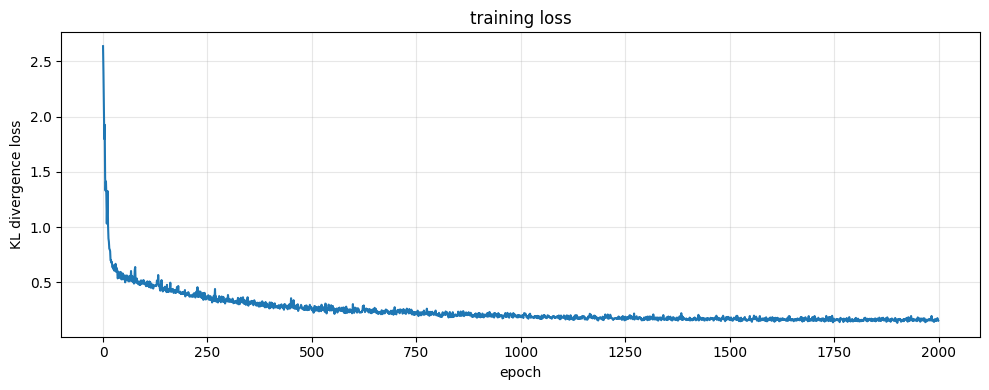

In [212]:
loss_history = train(model, data, num_epochs=2000)
plot_loss(loss_history)

### Testing

In [213]:
# --- get predictions ---
model.eval()
with torch.no_grad():
    y_hat, _, _ = model(data)

y_hat_np = y_hat.numpy()       # [3144 x 30]
y_true_np = data['county'].y.numpy()  # [3144 x 30]

# --- team color palette ---
team_colors = {
    'atlanta_hawks':        '#E03A3E',
    'boston_celtics':       '#007A33',
    'brooklyn_nets':        '#000000',
    'charlotte_hornets':    '#1D1160',
    'chicago_bulls':        '#CE1141',
    'cleveland_cavaliers':  '#860038',
    'dallas_mavericks':     '#00538C',
    'denver_nuggets':       '#0E2240',
    'detroit_pistons':      '#C8102E',
    'golden_state_warriors':'#1D428A',
    'houston_rockets':      '#CE1141',
    'indiana_pacers':       '#002D62',
    'la_clippers':          '#C8102E',
    'los_angeles_lakers':   '#552583',
    'memphis_grizzlies':    '#5D76A9',
    'miami_heat':           '#98002E',
    'milwaukee_bucks':      '#00471B',
    'minnesota_timberwolves':'#0C2340',
    'new_orleans_pelicans': '#0C2340',
    'new_york_knicks':      '#006BB6',
    'oklahoma_city_thunder':'#007AC1',
    'orlando_magic':        '#0077C0',
    'philadelphia_76ers':   '#006BB6',
    'phoenix_suns':         '#1D1160',
    'portland_trail_blazers':'#E03A3E',
    'sacramento_kings':     '#5A2D81',
    'san_antonio_spurs':    '#C4CED4',
    'toronto_raptors':      '#CE1141',
    'utah_jazz':            '#002B5C',
    'washington_wizards':   '#002B5C',
}

# --- prepare GeoDataFrame ---
plot_gdf = county_gdf.to_crs('EPSG:4326').copy()

plot_gdf['top_team_pred'] = [affinity_cols[i] for i in y_hat_np.argmax(axis=1)]
plot_gdf['top_team_true'] = [affinity_cols[i] for i in y_true_np.argmax(axis=1)]
plot_gdf['color_pred'] = plot_gdf['top_team_pred'].map(team_colors)
plot_gdf['color_true'] = plot_gdf['top_team_true'].map(team_colors)

# --- tooltip builder ---
def build_tooltip(county_name, state_code, affinities, label):
    ranked = sorted(
        zip(affinity_cols, affinities),
        key=lambda x: x[1],
        reverse=True
    )
    lines = [
        f"<b>{county_name}, {state_code}</b> "
        f"<span style='color:#888'>({label})</span><br><br>"
    ]
    for team, pct in ranked:
        bar_width = int(pct * 200)
        lines.append(
            f"<div style='display:flex;align-items:center;margin-bottom:2px'>"
            f"<span style='width:180px;font-size:10px'>"
            f"{team.replace('_', ' ').title()}</span>"
            f"<div style='width:{bar_width}px;height:8px;"
            f"background:{team_colors[team]};border-radius:2px;margin-right:4px'></div>"
            f"<span style='font-size:10px'>{pct*100:.1f}%</span>"
            f"</div>"
        )
    return ''.join(lines)

# build tooltips for both layers
plot_gdf['tooltip_pred'] = [
    build_tooltip(row['county_name'], row['state_code'], y_hat_np[idx], 'predicted')
    for idx, row in plot_gdf.iterrows()
]
plot_gdf['tooltip_true'] = [
    build_tooltip(row['county_name'], row['state_code'], y_true_np[idx], 'observed')
    for idx, row in plot_gdf.iterrows()
]

# --- build map ---
m = folium.Map(
    location=[39.5, -98.35],
    zoom_start=5,
    tiles='CartoDB positron'
)

# helper to build a GeoJson layer
def build_layer(gdf, color_col, tooltip_col, layer_name):
    layer = folium.FeatureGroup(name=layer_name, show=True)
    for idx, row in gdf.iterrows():
        geojson = {
            'type': 'Feature',
            'geometry': mapping(row.geometry),
            'properties': {'tooltip': row[tooltip_col]}
        }
        folium.GeoJson(
            geojson,
            style_function=lambda feature, color=row[color_col]: {
                'fillColor': color,
                'color': 'white',
                'weight': 0.3,
                'fillOpacity': 0.7
            },
            tooltip=folium.GeoJsonTooltip(
                fields=['tooltip'],
                aliases=[''],
                labels=False,
                sticky=True,
                style=(
                    'background-color: white;'
                    'border: 1px solid #ccc;'
                    'border-radius: 4px;'
                    'padding: 8px;'
                    'font-family: sans-serif;'
                    'font-size: 11px;'
                    'max-height: 350px;'
                    'overflow-y: auto;'
                    'min-width: 280px;'
                )
            )
        ).add_to(layer)
    return layer

print("building predicted layer...")
pred_layer = build_layer(plot_gdf, 'color_pred', 'tooltip_pred', 'Predicted')
pred_layer.add_to(m)

print("building observed layer...")
true_layer = build_layer(plot_gdf, 'color_true', 'tooltip_true', 'Observed')
true_layer.add_to(m)

# layer control toggle — top right corner
folium.LayerControl(position='topright', collapsed=False).add_to(m)

# --- legend ---
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 12px; border-radius: 6px;
     border: 1px solid #ccc; font-size: 11px; max-height: 420px;
     overflow-y: auto; font-family: sans-serif;">
<b>Top team by county</b><br>
<span style='color:#888;font-size:10px'>toggle layers top-right</span><br><br>
"""
for team, color in team_colors.items():
    legend_html += (
        f'<div style="display:flex;align-items:center;margin-bottom:3px">'
        f'<div style="width:14px;height:14px;background:{color};'
        f'margin-right:6px;border-radius:2px;flex-shrink:0"></div>'
        f'{team.replace("_", " ").title()}</div>'
    )
legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

m.save('nba_fandom_map.html')
print("saved as nba_fandom_map.html")

building predicted layer...
building observed layer...
saved as nba_fandom_map.html


In [215]:
# measure prediction variance across counties within each DMA
# if this collapses toward zero, over-smoothing is occurring
model.eval()
with torch.no_grad():
    y_hat, _, _ = model(data)

y_hat_np = y_hat.numpy()

# compute std of predictions within each DMA
for dma_name, dma_i in list(dma_to_idx.items())[:5]:
    mask = county_gdf['dma'] == dma_name
    if mask.sum() > 1:
        within_dma_std = y_hat_np[mask].std(axis=0).mean()
        print(f"{dma_name:<40} counties: {mask.sum():3d}  within-DMA std: {within_dma_std:.4f}")

# check some specific markets of interest
markets_to_check = [
    'Los Angeles',
    'New York',
    'San Francisco-Oakland-San Jose',
    'Boston',
    'Chicago',
    'Miami-Ft. Lauderdale',
]

for dma_name in markets_to_check:
    # partial match in case DMA name isn't exact
    matches = [d for d in dma_to_idx.keys() if any(m in d for m in [dma_name])]
    for match in matches:
        mask = county_gdf['dma'] == match
        if mask.sum() > 1:
            within_dma_std = y_hat_np[mask].std(axis=0).mean()
            print(f"{match:<45} counties: {mask.sum():3d}  within-DMA std: {within_dma_std:.4f}")

Tallahassee FL-Thomasville GA            counties:  18  within-DMA std: 0.0056
Terre Haute IN                           counties:  15  within-DMA std: 0.0068
Portland-Auburn ME                       counties:  11  within-DMA std: 0.0060
Duluth MN-Superior WI                    counties:  12  within-DMA std: 0.0175
Minot-Bismarck-Dickinson(Williston) ND   counties:  40  within-DMA std: 0.0161
Los Angeles CA                                counties:   6  within-DMA std: 0.0061
New York NY                                   counties:  30  within-DMA std: 0.0083
San Francisco-Oakland-San Jose CA             counties:  10  within-DMA std: 0.0071
Boston MA-Manchester NH                       counties:  16  within-DMA std: 0.0075
Chicago IL                                    counties:  16  within-DMA std: 0.0076
Miami-Ft. Lauderdale FL                       counties:   3  within-DMA std: 0.0017


## Conclusion

[[ go back to the top ]](#Table-of-contents)

## References

[[ go back to the top ]](#Table-of-contents)